<p align="center">
  <img src="https://raw.githubusercontent.com/Sanofi-Public/MIPHEI-ViT/main/MIPHEI_logo.svg" alt="MIPHEI-ViT Logo" style="height:250px;">
</p>

<p align="center">
  <a href="https://www.sciencedirect.com/science/article/pii/S0010482526001277" target="_blank" rel="noopener noreferrer" style="display: inline-block; vertical-align: middle;">
    <img src="https://img.shields.io/badge/CBM-Paper-orange?logo=elsevier" height="25">
  </a>
  <a href="https://arxiv.org/abs/2505.10294" target="_blank" rel="noopener noreferrer" style="display: inline-block; vertical-align: middle;">
    <img src="https://img.shields.io/badge/arXiv-Paper-b31b1b?logo=arxiv&logoColor=white" height="25">
  </a>
  <a href="https://github.com/Sanofi-Public/MIPHEI-ViT" target="_blank" rel="noopener noreferrer" style="display: inline-block; vertical-align: middle;">
    <img src="https://img.shields.io/badge/GitHub-Code-black?logo=github" height="25">
  </a>
  <a href="https://huggingface.co/Estabousi/MIPHEI-vit" target="_blank" rel="noopener noreferrer" style="display: inline-block; vertical-align: middle;">
    <img src="https://img.shields.io/badge/HuggingFace-Model-yellow?logo=huggingface" height="25">
  </a>
  <a href="https://zenodo.org/records/15340874" target="_blank" rel="noopener noreferrer" style="display: inline-block; vertical-align: middle;">
    <img src="https://img.shields.io/badge/Zenodo-Dataset-blue?logo=zenodo" height="25">
  </a>
</p>

# ⚙️ Environment Setup

Please select a GPU T4 instance: **Runtime > Change runtime type > Hardware accelerator** to **GPU T4**

In [ ]:
# Download Val and Test data from our preprocessed data of ORION-CRC
# Takes about 10 minutes

# You can replace this with an other dataset to download

!gdown --fuzzy https://drive.google.com/file/d/1Y4NO7kazlAAHDwuh0GJMR_NYSzuRMVOP/view?usp=drive_link
!7z x -mmt=on val_test_ORIONCRC_dataset_tile_20x.zip
!rm val_test_ORIONCRC_dataset_tile_20x.zip
!curl -L \
  -o val_test_ORIONCRC_dataset_tile_20x/val_test_nuclei_dataframe.parquet \
  "https://drive.usercontent.google.com/download?id=1XbZX3dlfzBZTVDOnbPYRzbCrs5xX2sMX&export=download"

In [5]:
# Download the MIPHEI weights

import os
import urllib.request

RELEASE = "v1.0.0"
BASE_URL = f"https://github.com/Sanofi-Public/MIPHEI-ViT/releases/download/{RELEASE}"

FILES = [
    "model.safetensors",
    "config.yaml",
    "LICENSE",
    "logreg.pth",
    "model.py",
    "requirements.txt",
]


def download(url, filepath):
    try:
        print(f"  ⬇️  Downloading {os.path.basename(filepath)} ... ", end="", flush=True)
        urllib.request.urlretrieve(url, filepath)
        print("✓")
    except Exception as e:
        print("✗ (failed)")
        print(f"    Error: {e}")


out_dir = "MIPHEI-vit"
os.makedirs(out_dir, exist_ok=True)

print(f"📦 Downloading MIPHEI-ViT release assets ({RELEASE})...")
print(f"📁 Destination: {os.path.abspath(out_dir)}\n")

for fname in FILES:
    url = f"{BASE_URL}/{fname}"
    filepath = os.path.join(out_dir, fname)
    download(url, filepath)

print("\n✔ All downloads completed.")

📦 Downloading MIPHEI-ViT release assets (v1.0.0)...
📁 Destination: /content/MIPHEI-vit

  ⬇️  Downloading model.safetensors ... ✓
  ⬇️  Downloading config.yaml ... ✓
  ⬇️  Downloading LICENSE ... ✓
  ⬇️  Downloading logreg.pth ... ✓
  ⬇️  Downloading model.py ... ✓
  ⬇️  Downloading requirements.txt ... ✓

✔ All downloads completed.


In [14]:
# Install dependencies

%cd /content/MIPHEI-vit

!pip install uv
!uv pip install cellpose==3.1.1.2 scikit-image scipy -q
!uv pip install -r requirements.txt

!pip cache purge
!uv cache clean

/content/MIPHEI-vit
Using Python 3.12.12 environment at: /usr
Checked 6 packages in 92ms
Files removed: 0
Clearing cache at: /root/.cache/uv
Removed 318 files (127.4MiB)


In [ ]:
!hf auth login

# Run MIPHEI on Tiles

In [1]:
%cd /content/MIPHEI-vit

/content/MIPHEI-vit


In [2]:
import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as T
from pathlib import Path
import numpy as np
from omegaconf import OmegaConf

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [3]:
HE_DIR = "/content/val_test_ORIONCRC_dataset_tile_20x/he"  # Adapt if it is another dataset

In [4]:
from safetensors.torch import load_file
from model import MIPHEIViT, Encoder, Detail_Capture, get_hoptimus0_hf, merge_lora_weights, validate_load_info


def load_miphei(config, img_size, weights_path):
  nc_out = len(config.data.targ_channel_names)
  hoptimus_hf_id = "bioptimus/H-optimus-0"

  vit = get_hoptimus0_hf(hoptimus_hf_id)
  vit.set_input_size(img_size=(img_size, img_size))
  encoder = Encoder(vit)
  decoder = Detail_Capture(emb_chans=encoder.embed_dim, out_chans=nc_out, activation=nn.Tanh())
  model = MIPHEIViT(encoder=encoder, decoder=decoder)
  state_dict = load_file(weights_path)
  state_dict = merge_lora_weights(model, state_dict)
  load_info = model.load_state_dict(state_dict, strict=False)
  validate_load_info(load_info)
  return model

In [5]:
if "model" in globals():  # avoid RAM issue
    try:
        del model
    except Exception:
        pass

    import gc; gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

config = OmegaConf.load("config.yaml")
channel_names = config.data.targ_channel_names
nc_out = len(channel_names)

width = height = 256  # 256 but you can change to width, height power of 2 and at least 128

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.empty_cache()
model = load_miphei(config, img_size=width, weights_path="model.safetensors")
model.set_input_size((width, height))
model = model.eval().to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [6]:
transform = T.Compose([
    T.Resize((width, height)),
    T.ToTensor(),  # Converts to shape [3, H, W], range [0,1]
    T.Normalize(
        mean=np.asarray(config.data.normalization.mean) / 255,  #(0.485, 0.456, 0.406),
        std=np.asarray(config.data.normalization.std) / 255,  #(0.229, 0.224, 0.225)
    ),  # H-optimus-0 normalization
])


In [7]:
image_paths = [str(fn) for fn in Path(HE_DIR).glob("*.jpeg")]
len(image_paths)

23354

## Multiplex Immunofluorescence tile prediction

In [15]:
img = Image.open(image_paths[np.random.randint(len(image_paths))]).convert("RGB").crop((38, 38, 294, 294))  # central crop
tile_tensor = transform(img).unsqueeze(0)  # Add batch dim: [1, 3, width, height]

# Predict mIF channels
with torch.inference_mode():
  with torch.autocast(device_type=device, dtype=torch.float16, enabled=(device != "cpu")):
    mif_pred = model(tile_tensor.to(device))  # [16, width, height]
    mif_pred = model(tile_tensor.to(device)).squeeze()  # Output: [16, width, height]
    mif_pred = (mif_pred.clamp(-0.9, 0.9) + 0.9) / 1.8  # [-0.9, 0.9] -> [0., 1.]
    mif_pred = (mif_pred * 255).to(torch.uint8)
    mif_pred = mif_pred.permute((1, 2, 0)).cpu()

/tmp/ipykernel_39026/3373937739.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


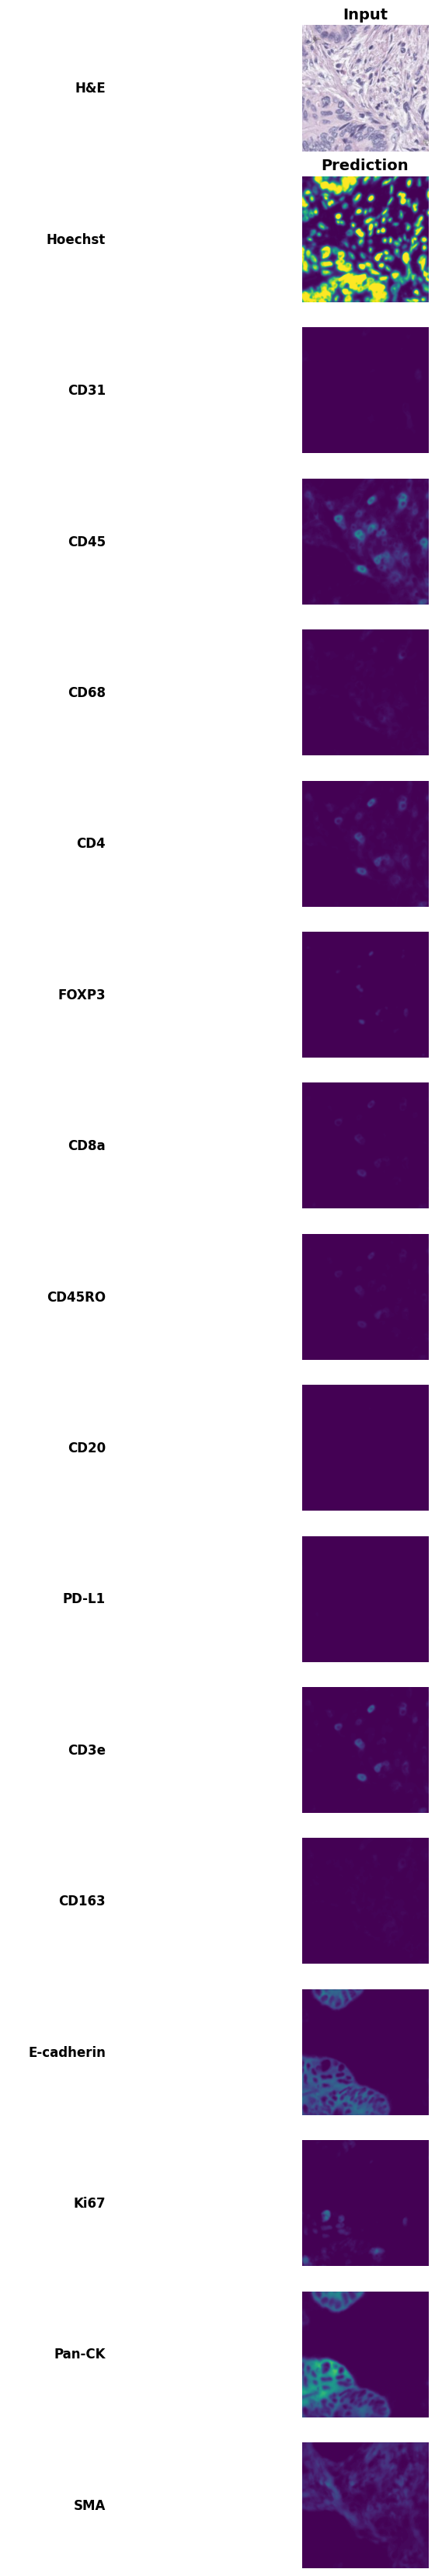

In [16]:
n_channels = len(channel_names)
fig = plt.figure(figsize=(10, 2.5 * (n_channels + 1)))
gs = gridspec.GridSpec(n_channels + 1, 2, width_ratios=[0.2, 1], wspace=0.05)

ax_label = fig.add_subplot(gs[0, 0])
ax_label.axis("off")
ax_label.text(1.0, 0.5, "H&E",
              va='center', ha='right', fontsize=12, fontweight='bold')

ax_img = fig.add_subplot(gs[0, 1])
ax_img.imshow(img)
ax_img.axis("off")
ax_img.set_title("Input", fontsize=14, fontweight="bold")

for i in range(n_channels):
    row = i + 1  # shift by 1

    # Label column
    ax_label = fig.add_subplot(gs[row, 0])
    ax_label.axis("off")
    ax_label.text(1.0, 0.5, channel_names[i],
                  va='center', ha='right', fontsize=12, fontweight='bold')

    # Prediction
    ax_pred = fig.add_subplot(gs[row, 1])
    ax_pred.imshow(mif_pred[..., i], vmin=0, vmax=100, cmap='viridis')
    ax_pred.axis("off")
    if i == 0:
        ax_pred.set_title("Prediction", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## Cell Type Prediction with MIPHEI and CellPose

Here we combine MIPHEI with CellPose applied on H&E images. Using both predicted mIF and CellPose masks, we apply mean nuclei pooling to extract mean predicted cell expressions for each nuclei instances. We then apply a cell linear classifier to predict cell types from these cell expressions.

In [17]:
#@title Cell Prediction Utils
#@markdown MeanCellExtrator allows to extract mean mIF intensities per images

import torch.nn as nn
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import binary_dilation, disk


class MeanCellExtrator(nn.Module):

    def forward(self, pred, nuclei):
        """
        Blabla

        Args:
            pred (torch.Tensor): Predicted tensor of shape [B, C, H, W].
            nuclei (torch.Tensor): Nuclei label tensor of shape [B, 1, H, W].

        Returns:
            torch.Tensor: L1 loss between extracted mean intensities.
        """
        # Downsample pred, target, and nuclei
        if nuclei.ndim == 3:
            nuclei = torch.unsqueeze(nuclei, dim=1).long()

        # Extract mean intensities for both pred and target
        pred_means, cell_ids = self.extract_mean(pred, nuclei)
        return pred_means, cell_ids

    def extract_mean(self, pred, nuclei):
        """
        Extract mean intensities for prediction using shared nuclei computations.

        Args:
            pred (torch.Tensor): Predicted tensor of shape [B, C, H, W].
            nuclei (torch.Tensor): Nuclei label tensor of shape [B, 1, H, W].

        Returns:
            torch.Tensor: Mean intensities for prediction, shape [num_labels, C].
            list[torch.Tensor]: Unique cell IDs for each batch element.
        """
        batch_size, num_channels, height, width = pred.shape

        # Prepare outputs
        all_pred_means = []
        all_cell_ids = []

        for b in range(batch_size):
            # Process each batch independently
            nuclei_b = nuclei[b, 0]  # Shape: [H, W]
            pred_b = pred[b]  # Shape: [C, H, W]

            # Create a binary mask for non-background pixels
            nuclei_binary = nuclei_b > 0

            # Apply the binary mask to nuclei
            nuclei_flat = nuclei_b[nuclei_binary]  # Shape: [num_valid_pixels]
            if nuclei_flat.numel() == 0:  # No valid regions
                all_pred_means.append(torch.zeros((0, num_channels), dtype=pred.dtype, device=pred.device))
                all_cell_ids.append(torch.empty(0, dtype=nuclei_b.dtype, device=nuclei_b.device))
                continue

            # Get unique labels and their indices
            unique_labels, inverse_indices = torch.unique(nuclei_flat, return_inverse=True)

            # Apply the mask to pred and target, flatten and preserve the channel dimension
            pred_flat = pred_b.permute(1, 2, 0)[nuclei_binary]  # Shape: [num_valid_pixels, C]

            # Compute sums per region and channel for pred and target
            pred_sums = torch.zeros((unique_labels.shape[0], num_channels), dtype=pred.dtype, device=pred.device).scatter_add_(
                0, inverse_indices.unsqueeze(1).expand(-1, num_channels), pred_flat
            )

            # Compute counts per region
            region_counts = torch.zeros(unique_labels.shape[0], dtype=torch.float32, device=nuclei.device).scatter_add_(
                0, inverse_indices, torch.ones_like(nuclei_flat, dtype=torch.float32)
            )

            # Compute mean intensities
            pred_means = pred_sums / region_counts.unsqueeze(1)

            # Append results
            all_pred_means.append(pred_means)
            all_cell_ids.append(unique_labels)

        # Concatenate results across batches
        pred_means = torch.cat(all_pred_means, dim=0)
        cell_ids = torch.cat(all_cell_ids, dim=0)

        return pred_means.to(pred.dtype), cell_ids


def inference_cellpose(x, cellpose_model, radius=None):
    nuclei_mask, _, _, _ = cellpose_model.eval(
            x,
            channels=[0, 0],
            diameter=None,
            min_size=15,
            normalize=True,
            invert=True,
            flow_threshold=0.4,
    )

    if radius is not None:
        # watershed nuclei expansion
        binary = nuclei_mask > 0
        dilated_mask = binary_dilation(binary, footprint=disk(radius))
        distance = ndi.distance_transform_edt(~binary)
        nuclei_mask = watershed(-distance, markers=nuclei_mask, mask=dilated_mask, watershed_line=False)
    return nuclei_mask


def create_nuclei_types(nuclei_mask_torch, cell_predictions, cell_ids):
    height, width = nuclei_mask_torch.shape[2], nuclei_mask_torch.shape[3]
    nuclei_types_torch = torch.zeros((1, 15, height, width), dtype=torch.bool)

    for idx_class in range(15):
        cell_ids_class = cell_ids[cell_predictions[..., idx_class]]
        nuclei_types_torch[:, idx_class] = torch.isin(nuclei_mask_torch, cell_ids_class).cpu()
    return nuclei_types_torch

In [18]:
from cellpose import models

cellpose_model = models.Cellpose(model_type="nuclei", gpu=device == "cuda")
mean_extractor = MeanCellExtrator().to(device)
n_marker = nc_out - 1
logreg = torch.nn.Linear(15, n_marker)
logreg_state_dict = torch.load("logreg.pth", map_location="cpu")
logreg.load_state_dict(logreg_state_dict)
logreg.eval().to(device)

CLASS_CELL_NAMES = [
    "CD31_pos", "CD45_pos", "CD68_pos", "CD4_pos", "FOXP3_pos", "CD8a_pos",
    "CD45RO_pos", "CD20_pos", "PD-L1_pos", "CD3e_pos", "CD163_pos", "E-cadherin_pos",
    "Ki67_pos", "Pan-CK_pos", "SMA_pos"
  ]

Linear(in_features=15, out_features=15, bias=True)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


image = Image.open(image_paths[np.random.randint(len(image_paths))]).convert("RGB").crop((38, 38, 294, 294))
input_tensor = transform(image).unsqueeze(0)

with torch.inference_mode():
    instance_mask = inference_cellpose(np.asarray(image), cellpose_model, radius=None)
    instance_mask_torch = torch.from_numpy(instance_mask).unsqueeze(0).unsqueeze(0).to(device).long()

    with torch.autocast(device_type=device, dtype=torch.float16, enabled=(device != "cpu")):
        output_mif = model(input_tensor.to(device))

    output_mif = output_mif.clamp(-0.9, 0.9)
    pred_cell_means, cell_ids = mean_extractor(output_mif.float(), instance_mask_torch)
    pred_cell_means = (pred_cell_means + 0.9) / 1.8 * 255

    cell_predictions = torch.sigmoid(logreg(pred_cell_means[..., 1:])) > 0.5
    output_celltypes = create_nuclei_types(instance_mask_torch, cell_predictions, cell_ids)[0].cpu().numpy()


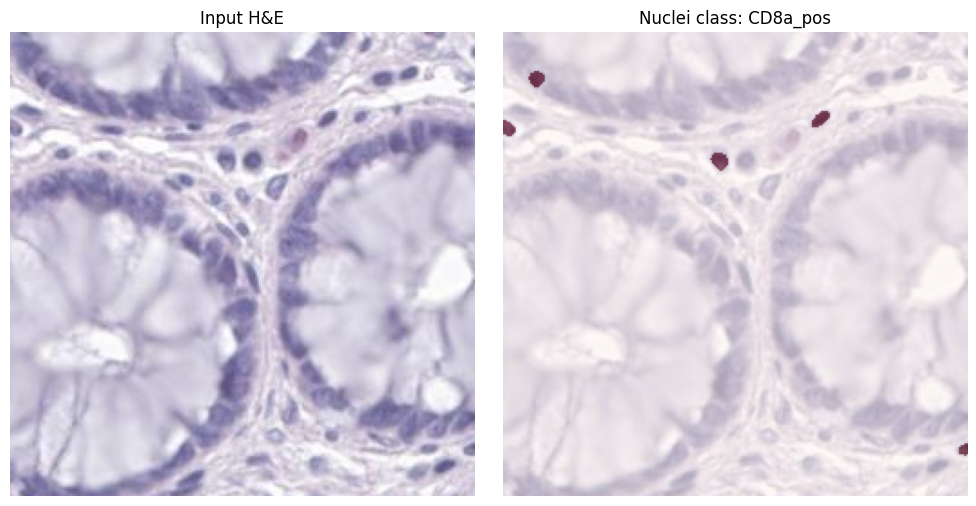

In [33]:
# Example: choose class by name
class_name = "CD8a_pos"  # change this
class_idx = CLASS_CELL_NAMES.index(class_name)

# Binary mask for the selected class
class_mask = output_celltypes[class_idx]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image)
axes[0].set_title("Input H&E")
axes[0].axis("off")

axes[1].imshow(image)
axes[1].imshow(class_mask, cmap="Reds", alpha=0.5)
axes[1].set_title(f"Nuclei class: {class_name}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# MIPHEI-VIT repository

In [ ]:
%cd /content
!git clone https://github.com/Sanofi-Public/MIPHEI-ViT.git
%cd /content/MIPHEI-ViT

!apt-get update
!apt-get install -y libvips-dev --no-install-recommends
!apt-get install -y libjemalloc2

!uv pip install pyvips==3.1.1
!uv pip install -r requirements.txt
!uv pip install -e slidevips-python -q
!uv cache clean

## WSI Inference

In [24]:
# Download GDC client

!wget https://gdc.cancer.gov/system/files/public/file/gdc-client_2.3_Ubuntu_x64-py3.8-ubuntu-20.04.zip
!unzip gdc-client_2.3_Ubuntu_x64-py3.8-ubuntu-20.04.zip
!unzip gdc-client_2.3_Ubuntu_x64.zip
!chmod +x gdc-client
!rm gdc-client_2.3_Ubuntu_x64-py3.8-ubuntu-20.04.zip gdc-client_2.3_Ubuntu_x64.zip

--2026-03-17 17:35:42--  https://gdc.cancer.gov/system/files/public/file/gdc-client_2.3_Ubuntu_x64-py3.8-ubuntu-20.04.zip
Resolving gdc.cancer.gov (gdc.cancer.gov)... 44.196.199.37, 44.207.160.109
Connecting to gdc.cancer.gov (gdc.cancer.gov)|44.196.199.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21987739 (21M) [application/zip]
Saving to: ‘gdc-client_2.3_Ubuntu_x64-py3.8-ubuntu-20.04.zip’

gdc-client_2.3_Ubun 100%[===================>]  20.97M  29.6MB/s    in 0.7s    

2026-03-17 17:35:43 (29.6 MB/s) - ‘gdc-client_2.3_Ubuntu_x64-py3.8-ubuntu-20.04.zip’ saved [21987739/21987739]

Archive:  gdc-client_2.3_Ubuntu_x64-py3.8-ubuntu-20.04.zip
  inflating: gdc-client_2.3_Ubuntu_x64.zip  
Archive:  gdc-client_2.3_Ubuntu_x64.zip
 extracting: gdc-client              


In [25]:
# Download TCGA CRC WSI
# You can select another one here: https://portal.gdc.cancer.gov/analysis_page?app=Downloads
# -> Primary site: Colon / Data type: Slide Image / Preservation Method: FFPE

uuid = "4f8edf30-a7bc-4a4a-a8bd-3af91fbddce2"

!./gdc-client download {uuid}
!mv {uuid}/*.svs /content
!rm -r {uuid}/

100% [############################################] Time:  0:00:11  14.1 MiB/s 
Successfully downloaded: 1


In [26]:
ls /content

gdc-client*   TCGA-A6-2684-01Z-00-DX1.be127778-e160-4ae3-9e5a-13a16eae2e7a.svs
MIPHEI-vit/   TCGA-G4-6298-01Z-00-DX1.83055d52-71f7-46ec-be53-11d86b19b4cf.svs
MIPHEI-ViT/   val_test_ORIONCRC_dataset_tile_20x/
sample_data/  wsi_predictions/


In [ ]:
# The scripts take 30-45 mins
# It is usually slower on colab

!mkdir -p /content/wsi_predictions/
!LD_PRELOAD=/usr/lib/x86_64-linux-gnu/libjemalloc.so.2 python run_wsi_inference.py --slide_path /content/TCGA-A6-2684-01Z-00-DX1.be127778-e160-4ae3-9e5a-13a16eae2e7a.svs  --checkpoint_dir /content/MIPHEI-vit/ --output_dir /content/wsi_predictions/

The script will generate a .ome.tiff in `/content/wsi_predictions/` directory that you can read in QuPath

## Evaluation

In [ ]:
!uv pip install pyarrow==23.0.1
!uv pip install -r requirements_benchmark.txt
!uv cache clean

Using Python 3.12.12 environment at: /usr
Resolved 22 packages in 288ms
Prepared 3 packages in 608ms
Uninstalled 3 packages in 474ms
Installed 3 packages in 71ms
 - diffusers==0.37.0
 + diffusers==0.35.2
 - huggingface-hub==1.6.0
 + huggingface-hub==0.36.2
 - transformers==5.0.0
 + transformers==4.57.1


### ORION Evaluation

You need to have downloaded Val + Test ORION-CRC tile dataset

In [53]:
# We run this to set the correct paths

from omegaconf import OmegaConf
from pathlib import Path
import pandas as pd

# Marker metadata csv
data = [
    ("Hoechst", 0),
    ("CD31", 1),
    ("CD45", 2),
    ("CD68", 3),
    ("CD4", 4),
    ("FOXP3", 5),
    ("CD8a", 6),
    ("CD45RO", 7),
    ("CD20", 8),
    ("PD-L1", 9),
    ("CD3e", 10),
    ("CD163", 11),
    ("E-cadherin", 12),
    ("PD-1", 13),
    ("Ki67", 14),
    ("Pan-CK", 15),
    ("SMA", 16),
]

df = pd.DataFrame(data, columns=["Marker Name", "Index"])
df.to_csv("/content/val_test_ORIONCRC_dataset_tile_20x/marker_metadata.csv", index=False)

# Link correct path in Orion data config
cfg = OmegaConf.load("configs/data/orion.yaml")
cfg.data.slide_dataframe_path = "/content/val_test_ORIONCRC_dataset_tile_20x/slide_dataframe.csv"
cfg.data.train_dataframe_path = None
cfg.data.val_dataframe_path = "/content/val_test_ORIONCRC_dataset_tile_20x/val_dataframe.csv"
cfg.data.test_dataframe_path = "/content/val_test_ORIONCRC_dataset_tile_20x/test_dataframe.csv"
cfg.data.nuclei_dataframe_path = "/content/val_test_ORIONCRC_dataset_tile_20x/val_test_nuclei_dataframe.parquet"
cfg.data.marker_metadata_path = "/content/val_test_ORIONCRC_dataset_tile_20x/marker_metadata.csv"
OmegaConf.save(cfg, "configs/data/orion.yaml")

# Link correct path for csvs containing nuclei subtypes
slide_dataframe = pd.read_csv("/content/val_test_ORIONCRC_dataset_tile_20x/slide_dataframe.csv")
if not slide_dataframe["nuclei_csv_path"].apply(lambda x: Path(x).exists()).any():  # avoid error if we run the cell multiple times
  slide_dataframe["nuclei_csv_path"] = slide_dataframe["nuclei_csv_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  slide_dataframe.to_csv("/content/val_test_ORIONCRC_dataset_tile_20x/slide_dataframe.csv", index=False)

# Link correct path for image, target and nuclei masks on Validation set
val_dataframe = pd.read_csv(cfg.data.val_dataframe_path)
if not Path(val_dataframe["image_path"].iloc[0]).exists():  # avoid error if we run the cell multiple times
  val_dataframe["image_path"] = val_dataframe["image_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  val_dataframe["target_path"] = val_dataframe["target_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  val_dataframe["nuclei_path"] = val_dataframe["nuclei_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  val_dataframe.to_csv(cfg.data.val_dataframe_path, index=False)

# Link correct path for image, target and nuclei masks on Test set
test_dataframe = pd.read_csv(cfg.data.test_dataframe_path)
if not Path(test_dataframe["image_path"].iloc[0]).exists():  # avoid error if we run the cell multiple times
  test_dataframe["image_path"] = test_dataframe["image_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  test_dataframe["target_path"] = test_dataframe["target_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  test_dataframe["nuclei_path"] = test_dataframe["nuclei_path"].apply(lambda x: str(Path("/content/val_test_ORIONCRC_dataset_tile_20x") / x))
  test_dataframe.to_csv(cfg.data.test_dataframe_path, index=False)

In [54]:
from io import StringIO

csv_data = """predicted_marker,hemit,orion,pathocell
Hoechst,Dapi,Hoechst,HOCHST13
CD31,NA,CD31,CD31
CD45,NA,CD45,CD45
CD68,NA,CD68,CD68
CD4,NA,CD4,CD4
FOXP3,NA,FOXP3,FOXP3
CD8a,NA,CD8a,CD8a
CD45RO,NA,CD45RO,CD45RO
CD20,NA,CD20,CD20
PD-L1,NA,PD-L1,PD-L1
CD3e,CD3,CD3e,CD3e
CD163,NA,CD163,CD163
E-cadherin,NA,E-cadherin,NA
Ki67,NA,Ki67,Ki67
Pan-CK,Pan-CK,Pan-CK,Cytokeratin
SMA,NA,SMA,SMA
"""

df = pd.read_csv(StringIO(csv_data))
df.to_csv("/content/MIPHEI-vit/marker_metadata.csv", index=False)

In [ ]:
# Takes about 30 minutes in Colab
!python run_benchmark.py --checkpoint_dir /content/MIPHEI-vit/ --model miphei --dataset orion --min_area=10


In [ ]:
pd.read_csv("/content/MIPHEI-vit/orion_logreg.csv.csv")

,Marker,ROC AUC,Balanced Accuracy,F1 Score
0,CD31_pos,0.887493,0.770851,0.373325
1,CD45_pos,0.898113,0.797775,0.677349
2,CD68_pos,0.851506,0.756759,0.355252
3,CD4_pos,0.894681,0.799347,0.550030
4,FOXP3_pos,0.871864,0.779587,0.109479
5,CD8a_pos,0.882658,0.781925,0.220742
6,CD45RO_pos,0.920990,0.826618,0.450494
7,CD20_pos,0.912720,0.786642,0.296280
8,PD-L1_pos,0.666710,0.602484,0.042230
9,CD3e_pos,0.902206,0.805827,0.558983


### Other dataset Evaluation

In [ ]:
# Follow instructions in datasets/README.md

%cd datasets/
!apt install aria2 -qq
!chmod u+x setup_data.sh
!./setup_data.sh --dataset pannuke --data_dir /content/data
%cd ../

In [ ]:
#!python run_benchmark.py --checkpoint_dir /content/MIPHEI-vit/--model miphei --dataset pathocell --min_area=0 --num_workers 0
#!python run_benchmark.py --checkpoint_dir /content/MIPHEI-vit/ --model miphei --dataset hemit --min_area=0
#!python run_benchmark.py --checkpoint_dir /content/MIPHEI-vit/ --model miphei --dataset lizard --min_area=0 --num_workers 0
!python run_benchmark.py --checkpoint_dir /content/MIPHEI-vit/ --model miphei --dataset pannuke --min_area=0